In [70]:
import pandas as pd
import matplotlib.pyplot as plt


In [71]:
stocks=pd.read_csv('BRK-A.csv')

###**DATA UNDERSTANDING AND CLEANING**
---
- Statistical summary
- Count missing values
- Find duplicate rows

In [72]:
stocks.head(3)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-09-04,126340.0,126654.0,126077.0,126279.0,126279.0,24300
1,2012-09-05,126315.0,128000.0,126315.0,127770.0,127770.0,68700
2,2012-09-06,128050.0,129597.0,128050.0,129597.0,129597.0,80900


`Adj Close`:The closing price adjusted for corporate actions such as dividends/splits.

`Volume`:The number of shares traded during that day.

In [73]:
stocks.shape

(1258, 7)

In [74]:

stocks.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [75]:
stocks.duplicated().sum()

np.int64(0)

In [76]:
stocks.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000
mean,200398.557234,201358.388712,199287.360890,200374.503180,200374.503180,10448.569157
std,33837.985810,33908.656288,33712.647745,33823.273041,33823.273041,25874.273189
min,126315.000000,126654.000000,125950.000000,126279.000000,126279.000000,100.000000
25%,174032.500000,174997.750000,173035.000000,174196.250000,174196.250000,200.000000
50%,205137.500000,206660.000000,204379.000000,205232.000000,205232.000000,300.000000
75%,219200.000000,220100.000000,218128.750000,219249.250000,219249.250000,600.000000
max,272800.000000,272885.000000,271040.000000,271450.000000,271450.000000,332700.000000


In [77]:
stocks.iloc[[0,-1]]


,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-09-04,126340.0,126654.0,126077.0,126279.0,126279.0,24300
1257,2017-09-01,272800.0,272885.0,271040.0,271062.0,271062.0,200


`Data Extracted for which dates`: From 2012-09-04 to 2017-09-01. Total of 1258 days.

In [78]:
print(stocks.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [79]:
stocks['Date']=pd.to_datetime(stocks['Date'])
stocks=stocks.set_index('Date')

In [80]:
print(stocks.columns)

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


<Axes: xlabel='Date'>

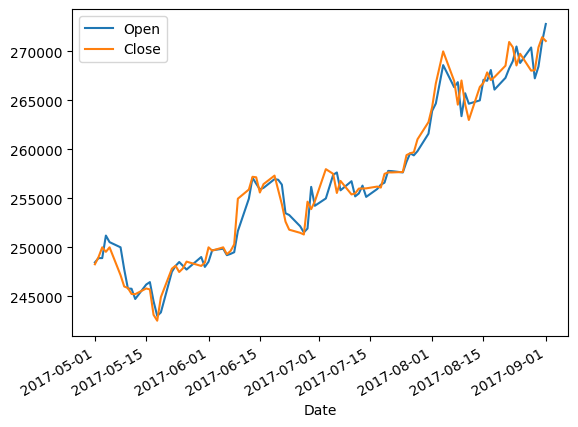

In [81]:
stocks.loc['2017-05-01':'2017-09-01'][['Open','Close']].plot(kind='line')

###**STOCK PRICE TREND**
---
- Yearly return
- Daily return
- Total return

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

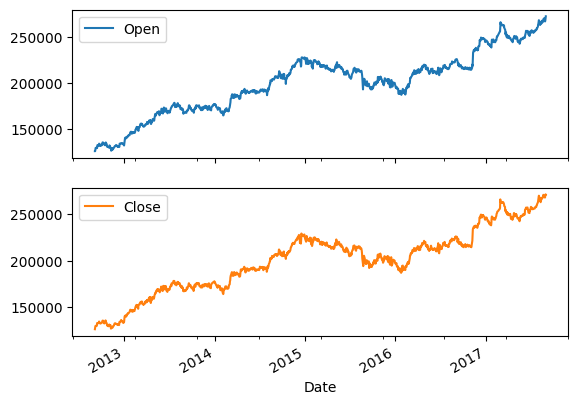

In [82]:
stocks[['Open','Close']].plot(kind='line',subplots=True)

In [83]:
print('Min Open:',stocks['Open'].min())
print('Max Open:',stocks['Open'].max())
print('Min Close:',stocks['Close'].min())
print('Max Close:',stocks['Close'].max())


Min Open: 126315.0
Max Open: 272800.0
Min Close: 126279.0
Max Close: 271450.0


In [84]:
Total_return=(stocks['Close'].iloc[-1]/stocks['Close'].iloc[0]-1)*100
print('Total return:',Total_return)

Total return: 114.65326776423632


In [85]:
stocks['Year']=stocks.index.year
yearly=stocks.groupby('Year')['Close'].agg(['first','last'])


<Axes: xlabel='Year', ylabel='% yearly return'>

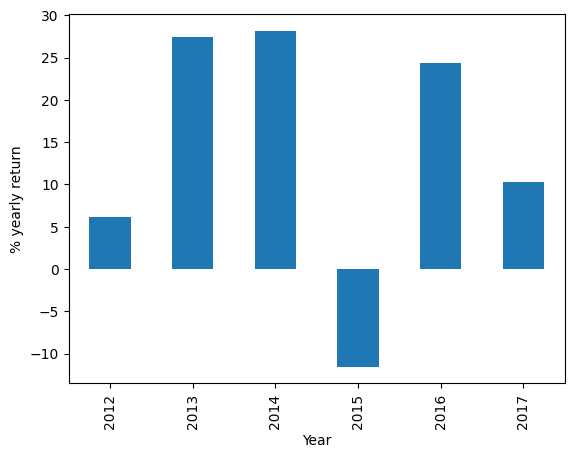

In [86]:
yearly['% return']=(yearly['last']/yearly['first']-1)*100
yearly['% return'].plot(kind='bar',ylabel='% yearly return')


<Axes: xlabel='Date', ylabel='% Daily return'>

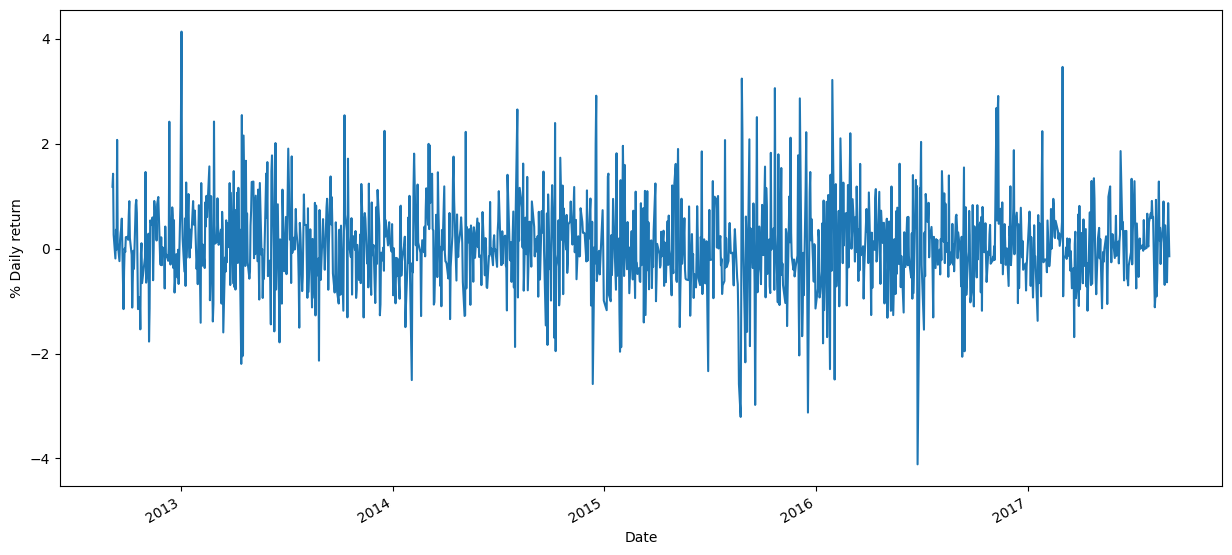

In [87]:
stocks['Daily return']=stocks['Close'].pct_change()*100
stocks['Daily return'].plot(kind='line',ylabel='% Daily return',figsize=(15,7))

In [88]:
stocks.nlargest(5,'Daily return')[['Daily return']]

,Daily return
Date,
2013-01-02,4.139937
2017-03-01,3.466744
2015-08-26,3.244078
2016-01-29,3.218269
2015-10-22,3.061531


In [89]:
stocks.nsmallest(5,'Daily return')[['Daily return']]

,Daily return
Date,
2016-06-24,-4.111492
2015-08-24,-3.207407
2015-12-18,-3.124378
2015-09-18,-2.978294
2014-12-12,-2.580071


###**VOLATILITY AND RISK**
---
- Standard deviation of daily return
- Rolling volatility
- Drawdown/Maximum drawdown


In [90]:
stocks['Daily return'].std()

0.8695724216713349

- Less than 1% represents, stocks were much less risky and volatile.
and saw very slight movement in daily return.

In [91]:
stocks['Rolling volatility']=stocks['Daily return'].rolling(30).std()

<Axes: xlabel='Date', ylabel='Rolling volatility'>

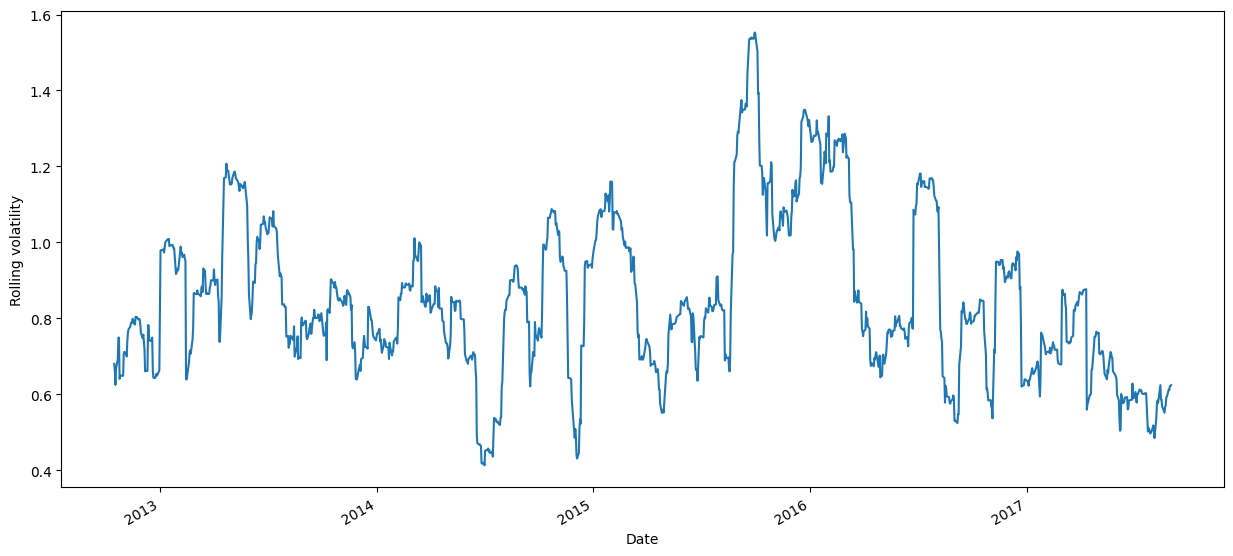

In [92]:
stocks['Rolling volatility'].plot(kind='line',ylabel="Rolling volatility",figsize=(15,7))

<Axes: xlabel='Date', ylabel='Drawdown'>

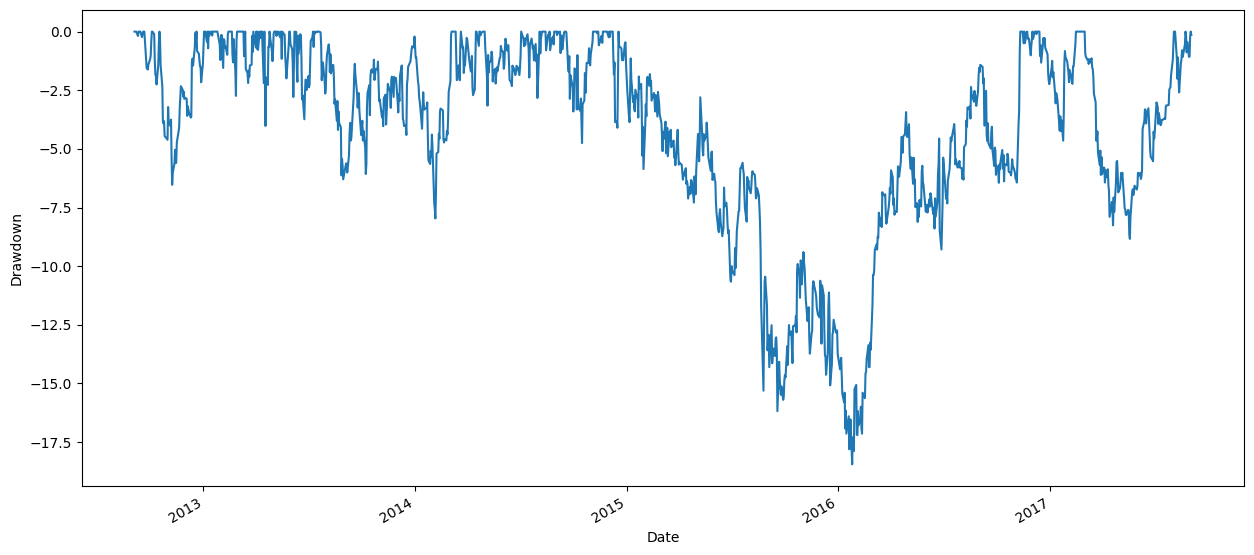

In [93]:
stocks['Peak']=stocks['Close'].cummax()
stocks['Drawdown']=(stocks['Close']/stocks['Peak']-1)*100
stocks['Drawdown'].plot(kind='line',ylabel='Drawdown',figsize=(15,7))

In [94]:
stocks.loc[stocks['Drawdown'].idxmin(),['Close','Peak','Drawdown']]

,2016-01-25
Close,187001.000000
Peak,229300.000000
Drawdown,-18.447013


- On 25 Jan 2016 Investor felt maximum drawdown.


###**ANALYZING TRADING VOLUME**
---
- Correlation between daily return and volume.


In [95]:
stocks[['Daily return','Volume']].corr()

,Daily return,Volume
Daily return,1.00000,0.07353
Volume,0.07353,1.00000


<Axes: xlabel='Volume', ylabel='Daily return'>

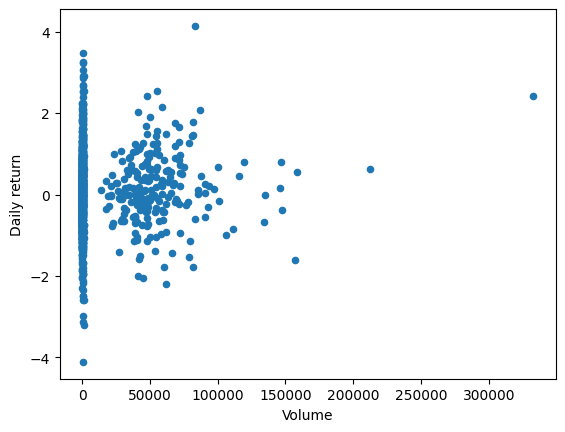

In [96]:
stocks.plot(kind='scatter',x='Volume',y='Daily return')

###**INTRADAY BEHAVIOUR**
---
- DAILY RANGE
- OPEN CLOSE BEHAVIOUR
- CLOSE POSITION

<Axes: xlabel='Date'>

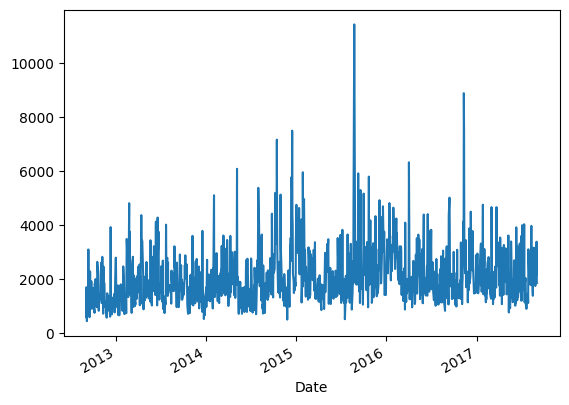

In [97]:
stocks['Daily range']=stocks['High']-stocks['Low']
stocks['Daily range'].plot(kind='line')

In [98]:
stocks['Daily range %']=((stocks['High']-stocks['Low'])/stocks['Open'])*100

<Axes: ylabel='Frequency'>

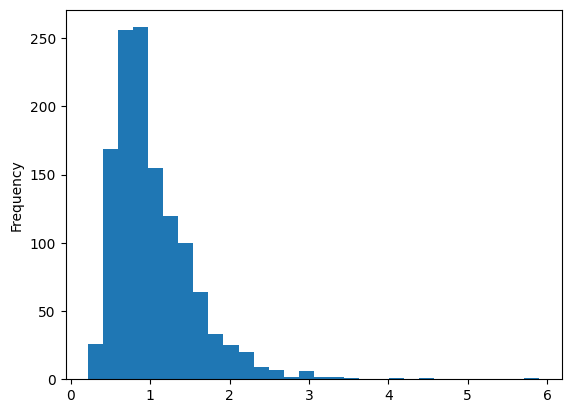

In [99]:
stocks['Daily range %'].plot(kind='hist',bins=30)

In [100]:
import seaborn as sns

<Axes: >

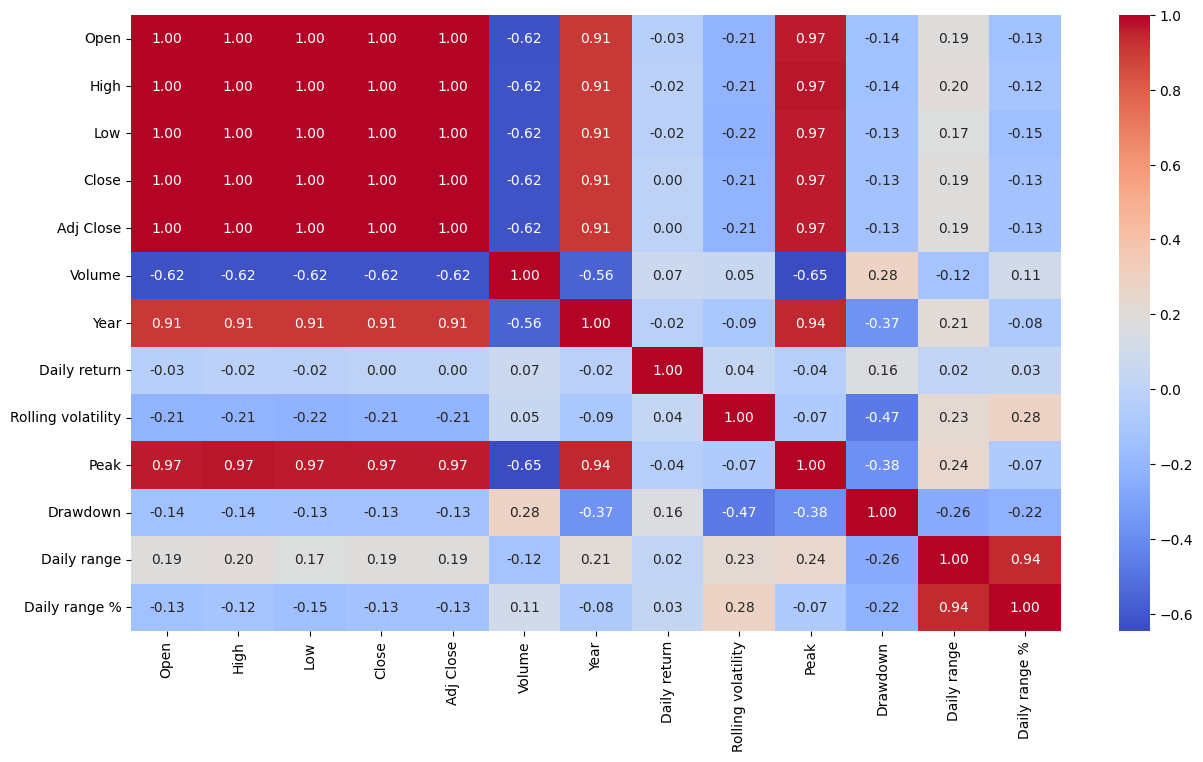

In [102]:
corr=stocks.corr(numeric_only=True)
plt.figure(figsize=(15, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')